# Pipeline MLOps - Wine Quality

**Integrantes:** Bryan Macas y Joseph Sangurima

## Objetivo

Construir un pipeline reproducible de Machine Learning para predecir la
calidad del vino a partir de sus características fisicoquímicas.

Se realizarán múltiples experimentos con diferentes configuraciones de
hiperparámetros y se utilizará MLflow para registrar parámetros, métricas
y modelos. Posteriormente, el mismo proceso será realizado con
Weights & Biases para comparar ambas herramientas.

## Dataset

Wine Quality - UCI Machine Learning Repository  
Licencia: CC BY 4.0  
DOI: 10.24432/C56S3T

In [4]:
%pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [5]:
import sys
import time
import platform

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import mlflow
import mlflow.sklearn

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

SEMILLA = 42

print("Python:", sys.version.split()[0])
print("Sistema:", platform.system())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)
print("MLflow:", mlflow.__version__)
print("Semilla:", SEMILLA)

Python: 3.13.2
Sistema: Linux
NumPy: 2.5.3
Pandas: 3.0.6
Scikit-learn: 1.9.1
MLflow: 3.16.1
Semilla: 42


In [6]:
wine_quality = fetch_ucirepo(id=186)

X = wine_quality.data.features.copy()
y = wine_quality.data.targets.copy()

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (6497, 11)
Dimensiones de y: (6497, 1)


In [7]:
print(wine_quality.metadata)

{'uci_id': 186, 'name': 'Wine Quality', 'repository_url': 'https://archive.ics.uci.edu/dataset/186/wine+quality', 'data_url': 'https://archive.ics.uci.edu/static/public/186/data.csv', 'abstract': 'Two datasets are included, related to red and white vinho verde wine samples, from the north of Portugal. The goal is to model wine quality based on physicochemical tests (see [Cortez et al., 2009], http://www3.dsi.uminho.pt/pcortez/wine/).', 'area': 'Business', 'tasks': ['Classification', 'Regression'], 'characteristics': ['Multivariate'], 'num_instances': 4898, 'num_features': 11, 'feature_types': ['Real'], 'demographics': [], 'target_col': ['quality'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2009, 'last_updated': 'Wed Nov 15 2023', 'dataset_doi': '10.24432/C56S3T', 'creators': ['Paulo Cortez', 'A. Cerdeira', 'F. Almeida', 'T. Matos', 'J. Reis'], 'intro_paper': {'ID': 252, 'type': 'NATIVE', 'title': 'Modeling wine preferences

In [8]:
wine_quality.variables

,name,role,type,demographic,description,units,missing_values
0,fixed_acidity,Feature,Continuous,None,NaN,None,no
1,volatile_acidity,Feature,Continuous,None,NaN,None,no
2,citric_acid,Feature,Continuous,None,NaN,None,no
3,residual_sugar,Feature,Continuous,None,NaN,None,no
4,chlorides,Feature,Continuous,None,NaN,None,no
5,free_sulfur_dioxide,Feature,Continuous,None,NaN,None,no
6,total_sulfur_dioxide,Feature,Continuous,None,NaN,None,no
7,density,Feature,Continuous,None,NaN,None,no
8,pH,Feature,Continuous,None,NaN,None,no
9,sulphates,Feature,Continuous,None,NaN,None,no


In [9]:
df = pd.concat([X, y], axis=1)

df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [10]:
print("Filas:", df.shape[0])
print("Columnas:", df.shape[1])

Filas: 6497
Columnas: 12


In [11]:
df.columns.tolist()

['fixed_acidity',
 'volatile_acidity',
 'citric_acid',
 'residual_sugar',
 'chlorides',
 'free_sulfur_dioxide',
 'total_sulfur_dioxide',
 'density',
 'pH',
 'sulphates',
 'alcohol',
 'quality']

## Análisis exploratorio de datos

En esta sección se analiza la estructura del dataset, tipos de variables,
valores faltantes, estadísticos descriptivos y distribución de la variable
objetivo.

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6497 entries, 0 to 6496
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         6497 non-null   float64
 1   volatile_acidity      6497 non-null   float64
 2   citric_acid           6497 non-null   float64
 3   residual_sugar        6497 non-null   float64
 4   chlorides             6497 non-null   float64
 5   free_sulfur_dioxide   6497 non-null   float64
 6   total_sulfur_dioxide  6497 non-null   float64
 7   density               6497 non-null   float64
 8   pH                    6497 non-null   float64
 9   sulphates             6497 non-null   float64
 10  alcohol               6497 non-null   float64
 11  quality               6497 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 609.2 KB


In [13]:
faltantes = df.isnull().sum()

faltantes

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [14]:
print("Total de valores faltantes:", faltantes.sum())

Total de valores faltantes: 0


In [15]:
duplicados = df.duplicated().sum()

print("Registros duplicados:", duplicados)

Registros duplicados: 1179


In [16]:
df["quality"].value_counts().sort_index()

quality
3      30
4     216
5    2138
6    2836
7    1079
8     193
9       5
Name: count, dtype: int64

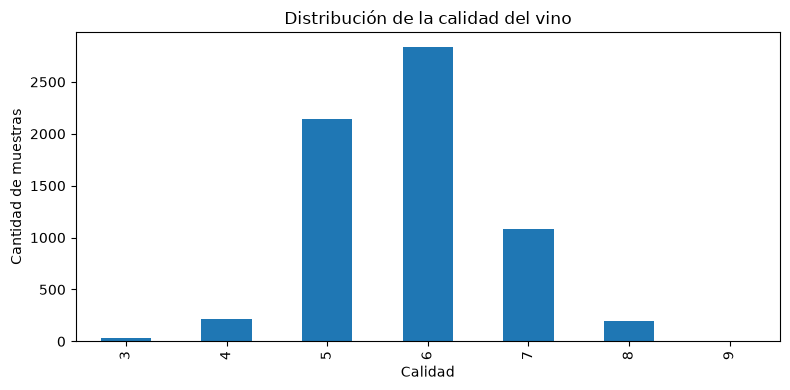

In [17]:
df["quality"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Distribución de la calidad del vino")
plt.xlabel("Calidad")
plt.ylabel("Cantidad de muestras")
plt.tight_layout()
plt.show()

In [18]:
correlaciones = (
    df.corr(numeric_only=True)["quality"]
    .sort_values(ascending=False)
)

correlaciones

quality                 1.000000
alcohol                 0.444319
citric_acid             0.085532
free_sulfur_dioxide     0.055463
sulphates               0.038485
pH                      0.019506
residual_sugar         -0.036980
total_sulfur_dioxide   -0.041385
fixed_acidity          -0.076743
chlorides              -0.200666
volatile_acidity       -0.265699
density                -0.305858
Name: quality, dtype: float64

### Tratamiento de registros duplicados

Durante el análisis exploratorio se identificaron registros completamente
duplicados. Estos registros se eliminarán antes de dividir el conjunto de
datos en entrenamiento y prueba para reducir el riesgo de que observaciones
idénticas aparezcan en ambos subconjuntos y produzcan una estimación
optimista del rendimiento del modelo.

In [19]:
filas_antes = len(df)

df = df.drop_duplicates().reset_index(drop=True)

filas_despues = len(df)

print("Filas antes:", filas_antes)
print("Filas después:", filas_despues)
print("Duplicados eliminados:", filas_antes - filas_despues)

Filas antes: 6497
Filas después: 5318
Duplicados eliminados: 1179


In [20]:
X = df.drop(columns=["quality"])
y = df["quality"]

In [21]:
print("X:", X.shape)
print("y:", y.shape)

X: (5318, 11)
y: (5318,)


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=SEMILLA
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (4254, 11)
Prueba: (1064, 11)


In [23]:
modelo_base = RandomForestRegressor(
    n_estimators=100,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=SEMILLA,
    n_jobs=-1
)

inicio = time.perf_counter()

modelo_base.fit(X_train, y_train)

predicciones = modelo_base.predict(X_test)

tiempo_base = time.perf_counter() - inicio

In [24]:
mae_base = mean_absolute_error(y_test, predicciones)

rmse_base = np.sqrt(
    mean_squared_error(y_test, predicciones)
)

r2_base = r2_score(y_test, predicciones)

print(f"MAE:  {mae_base:.4f}")
print(f"RMSE: {rmse_base:.4f}")
print(f"R²:   {r2_base:.4f}")
print(f"Tiempo: {tiempo_base:.4f} s")

MAE:  0.5099
RMSE: 0.6738
R²:   0.3948
Tiempo: 0.2002 s


In [25]:
baseline = pd.DataFrame({
    "modelo": ["RandomForestRegressor"],
    "n_estimators": [100],
    "max_depth": [None],
    "MAE": [mae_base],
    "RMSE": [rmse_base],
    "R2": [r2_base],
    "tiempo_segundos": [tiempo_base]
})

baseline

,modelo,n_estimators,max_depth,MAE,RMSE,R2,tiempo_segundos
0,RandomForestRegressor,100,None,0.509878,0.673774,0.394842,0.200216


In [26]:
mlflow.set_experiment("wine-quality-random-forest")

<Experiment: artifact_location=('/home/bryzcoll/Escritorio/9no/Ciencia de '
 'Datos/MLOps/mlops-wine-quality/notebooks/mlruns/2'), creation_time=1791164696189, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1791164696189, lifecycle_stage='active', name='wine-quality-random-forest', tags={}, trace_location=None, workspace='default'>

In [27]:
parametros = {
    "n_estimators": 100,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 1,
    "random_state": SEMILLA
}

In [28]:
with mlflow.start_run(run_name="rf-baseline") as run:

    inicio_total = time.perf_counter()

    inicio_entrenamiento = time.perf_counter()

    modelo = RandomForestRegressor(
        **parametros,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)
    predicciones = modelo.predict(X_test)

    tiempo_entrenamiento = (
        time.perf_counter() - inicio_entrenamiento
    )

    mae = mean_absolute_error(y_test, predicciones)
    rmse = np.sqrt(mean_squared_error(y_test, predicciones))
    r2 = r2_score(y_test, predicciones)

    mlflow.log_params(parametros)

    mlflow.log_metrics({
        "mae": mae,
        "rmse": rmse,
        "r2": r2,
        "tiempo_entrenamiento": tiempo_entrenamiento
    })

    mlflow.sklearn.log_model(
        sk_model=modelo,
        name="random_forest",
        skops_trusted_types=[
            "sklearn.tree._tree.Tree"
        ]
    )

    tiempo_total_mlflow = (
        time.perf_counter() - inicio_total
    )

    mlflow.log_metric(
        "tiempo_total_mlflow",
        tiempo_total_mlflow
    )

    print(f"Tiempo entrenamiento: {tiempo_entrenamiento:.4f} s")
    print(f"Tiempo total MLflow:   {tiempo_total_mlflow:.4f} s")

Tiempo entrenamiento: 0.2104 s
Tiempo total MLflow:   3.0821 s


In [29]:
configuraciones = [
    {
        "n_estimators": 50,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 5,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 300,
        "max_depth": 10,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 100,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 1
    },
    {
        "n_estimators": 200,
        "max_depth": None,
        "min_samples_split": 2,
        "min_samples_leaf": 2
    },
    {
        "n_estimators": 300,
        "max_depth": None,
        "min_samples_split": 5,
        "min_samples_leaf": 2
    }
]

## Experimentación con MLflow

Se ejecutarán diez configuraciones de Random Forest utilizando el mismo
dataset, división de entrenamiento/prueba y semilla aleatoria.

Para cada experimento se registrarán los hiperparámetros, MAE, RMSE,
R² y tiempos de ejecución.

In [30]:
resultados = []

mlflow.set_experiment("wine-quality-random-forest")

for i, config in enumerate(configuraciones, start=1):

    parametros = {
        **config,
        "random_state": SEMILLA
    }

    with mlflow.start_run(run_name=f"experimento-{i:02d}") as run:

        inicio_total = time.perf_counter()
        inicio_entrenamiento = time.perf_counter()

        modelo = RandomForestRegressor(
            **parametros,
            n_jobs=-1
        )

        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)

        tiempo_entrenamiento = (
            time.perf_counter() - inicio_entrenamiento
        )

        mae = mean_absolute_error(y_test, predicciones)
        rmse = np.sqrt(
            mean_squared_error(y_test, predicciones)
        )
        r2 = r2_score(y_test, predicciones)

        mlflow.log_params(parametros)

        mlflow.log_metrics({
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "tiempo_entrenamiento": tiempo_entrenamiento
        })

        mlflow.sklearn.log_model(
            sk_model=modelo,
            name="random_forest",
            skops_trusted_types=[
                "sklearn.tree._tree.Tree"
            ]
        )

        tiempo_total = time.perf_counter() - inicio_total

        mlflow.log_metric(
            "tiempo_total_mlflow",
            tiempo_total
        )

        resultados.append({
            "experimento": i,
            **config,
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "tiempo_entrenamiento": tiempo_entrenamiento,
            "tiempo_total_mlflow": tiempo_total,
            "run_id": run.info.run_id
        })

        print(
            f"Experimento {i:02d} | "
            f"RMSE={rmse:.4f} | "
            f"R²={r2:.4f}"
        )

Experimento 01 | RMSE=0.7071 | R²=0.3334
Experimento 02 | RMSE=0.7060 | R²=0.3357
Experimento 03 | RMSE=0.7058 | R²=0.3359
Experimento 04 | RMSE=0.6791 | R²=0.3853
Experimento 05 | RMSE=0.6780 | R²=0.3872
Experimento 06 | RMSE=0.6782 | R²=0.3869
Experimento 07 | RMSE=0.6738 | R²=0.3948
Experimento 08 | RMSE=0.6734 | R²=0.3955
Experimento 09 | RMSE=0.6716 | R²=0.3987
Experimento 10 | RMSE=0.6724 | R²=0.3974


In [31]:
df_resultados = pd.DataFrame(resultados)

df_resultados

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae,rmse,r2,tiempo_entrenamiento,tiempo_total_mlflow,run_id
0,1,50,5.0,2,1,0.542248,0.707135,0.333432,0.084430,2.125815,594f674e29d940529a0015bf345b2471
1,2,100,5.0,2,1,0.541286,0.705954,0.335655,0.147036,2.172233,a3c43ba1b77d4766be5f8db80378021f
2,3,200,5.0,2,1,0.541045,0.705845,0.335861,0.281888,2.486551,987264a6bb214a1da23146f6560fb26e
3,4,100,10.0,2,1,0.517887,0.679080,0.385272,0.179484,2.277415,a46b6e5cc94e425282747d0ddaed58fd
4,5,200,10.0,2,1,0.516168,0.678003,0.387220,0.307728,2.370158,c5fe78ab190249ea9e49f52e95d2b791
5,6,300,10.0,2,1,0.516125,0.678156,0.386945,0.417251,2.505994,595592b9a0c94500989f2b8fb15f779b
6,7,100,NaN,2,1,0.509878,0.673774,0.394842,0.189652,2.089490,9ca15e553b06451a846e5cce631c1172
7,8,200,NaN,5,1,0.510005,0.673414,0.395488,0.340321,2.430148,09099ec0025f4b4694bf6c8280ebea3d
8,9,200,NaN,2,2,0.507986,0.671642,0.398665,0.371395,2.479312,9b389d755369468180eedc65c4f11467
9,10,300,NaN,5,2,0.509009,0.672359,0.397381,0.475406,2.728644,8d8d06a25d4c4b35bd99586621d049ff


In [32]:
ranking = df_resultados.sort_values(
    by="rmse",
    ascending=True
).reset_index(drop=True)

ranking

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae,rmse,r2,tiempo_entrenamiento,tiempo_total_mlflow,run_id
0,9,200,NaN,2,2,0.507986,0.671642,0.398665,0.371395,2.479312,9b389d755369468180eedc65c4f11467
1,10,300,NaN,5,2,0.509009,0.672359,0.397381,0.475406,2.728644,8d8d06a25d4c4b35bd99586621d049ff
2,8,200,NaN,5,1,0.510005,0.673414,0.395488,0.340321,2.430148,09099ec0025f4b4694bf6c8280ebea3d
3,7,100,NaN,2,1,0.509878,0.673774,0.394842,0.189652,2.089490,9ca15e553b06451a846e5cce631c1172
4,5,200,10.0,2,1,0.516168,0.678003,0.387220,0.307728,2.370158,c5fe78ab190249ea9e49f52e95d2b791
5,6,300,10.0,2,1,0.516125,0.678156,0.386945,0.417251,2.505994,595592b9a0c94500989f2b8fb15f779b
6,4,100,10.0,2,1,0.517887,0.679080,0.385272,0.179484,2.277415,a46b6e5cc94e425282747d0ddaed58fd
7,3,200,5.0,2,1,0.541045,0.705845,0.335861,0.281888,2.486551,987264a6bb214a1da23146f6560fb26e
8,2,100,5.0,2,1,0.541286,0.705954,0.335655,0.147036,2.172233,a3c43ba1b77d4766be5f8db80378021f
9,1,50,5.0,2,1,0.542248,0.707135,0.333432,0.084430,2.125815,594f674e29d940529a0015bf345b2471


In [33]:
ranking[
    [
        "experimento",
        "n_estimators",
        "max_depth",
        "min_samples_split",
        "min_samples_leaf",
        "mae",
        "rmse",
        "r2",
        "tiempo_entrenamiento"
    ]
]

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae,rmse,r2,tiempo_entrenamiento
0,9,200,NaN,2,2,0.507986,0.671642,0.398665,0.371395
1,10,300,NaN,5,2,0.509009,0.672359,0.397381,0.475406
2,8,200,NaN,5,1,0.510005,0.673414,0.395488,0.340321
3,7,100,NaN,2,1,0.509878,0.673774,0.394842,0.189652
4,5,200,10.0,2,1,0.516168,0.678003,0.387220,0.307728
5,6,300,10.0,2,1,0.516125,0.678156,0.386945,0.417251
6,4,100,10.0,2,1,0.517887,0.679080,0.385272,0.179484
7,3,200,5.0,2,1,0.541045,0.705845,0.335861,0.281888
8,2,100,5.0,2,1,0.541286,0.705954,0.335655,0.147036
9,1,50,5.0,2,1,0.542248,0.707135,0.333432,0.084430


In [34]:
mejor = ranking.iloc[0]

print("Mejor experimento:", int(mejor["experimento"]))
print("RMSE:", round(mejor["rmse"], 4))
print("MAE:", round(mejor["mae"], 4))
print("R²:", round(mejor["r2"], 4))

print("\nConfiguración:")
print("n_estimators:", mejor["n_estimators"])
print("max_depth:", mejor["max_depth"])
print("min_samples_split:", mejor["min_samples_split"])
print("min_samples_leaf:", mejor["min_samples_leaf"])

Mejor experimento: 9
RMSE: 0.6716
MAE: 0.508
R²: 0.3987

Configuración:
n_estimators: 200
max_depth: nan
min_samples_split: 2
min_samples_leaf: 2


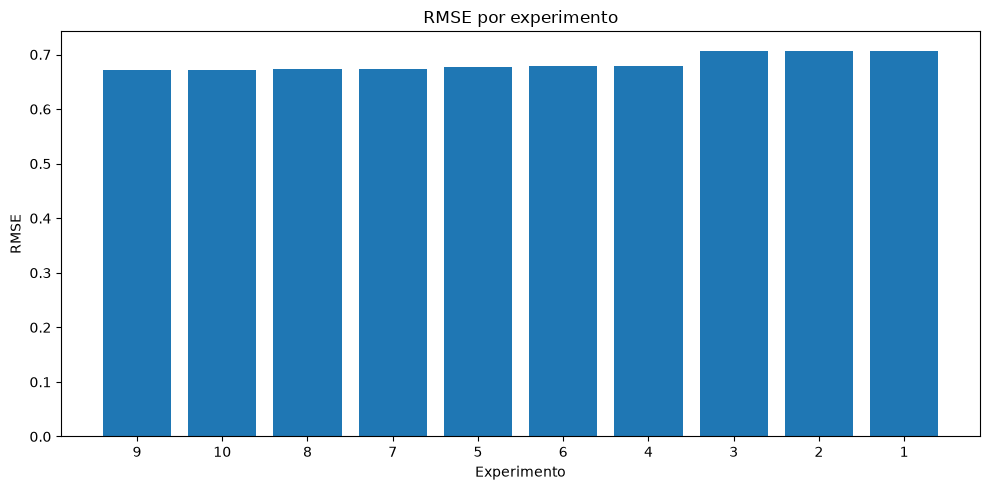

In [35]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["experimento"].astype(str),
    ranking["rmse"]
)

plt.xlabel("Experimento")
plt.ylabel("RMSE")
plt.title("RMSE por experimento")
plt.tight_layout()
plt.show()

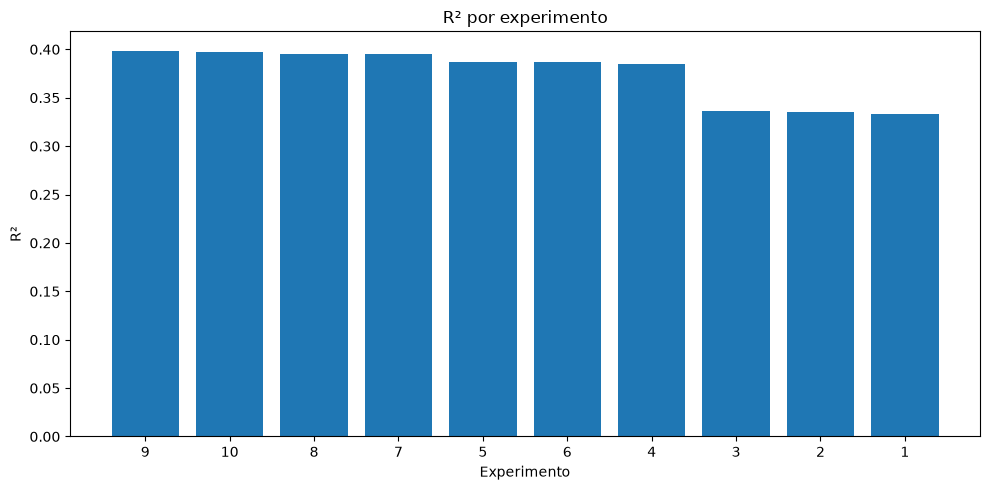

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    ranking["experimento"].astype(str),
    ranking["r2"]
)

plt.xlabel("Experimento")
plt.ylabel("R²")
plt.title("R² por experimento")
plt.tight_layout()
plt.show()

In [37]:
ranking.to_csv(
    "../results/metrics/mlflow_experimentos.csv",
    index=False
)

## Reproducción del mejor experimento

Se reproduce la configuración que obtuvo el menor RMSE para verificar
que, utilizando el mismo dataset, división de entrenamiento/prueba y
semilla aleatoria, se obtienen nuevamente los mismos resultados.

In [38]:
mejores_parametros = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "random_state": SEMILLA
}

modelo_reproducido = RandomForestRegressor(
    **mejores_parametros,
    n_jobs=-1
)

modelo_reproducido.fit(X_train, y_train)

pred_reproducidas = modelo_reproducido.predict(X_test)

mae_reproducido = mean_absolute_error(
    y_test,
    pred_reproducidas
)

rmse_reproducido = np.sqrt(
    mean_squared_error(
        y_test,
        pred_reproducidas
    )
)

r2_reproducido = r2_score(
    y_test,
    pred_reproducidas
)

print(f"MAE reproducido:  {mae_reproducido:.6f}")
print(f"RMSE reproducido: {rmse_reproducido:.6f}")
print(f"R² reproducido:   {r2_reproducido:.6f}")

MAE reproducido:  0.507986
RMSE reproducido: 0.671642
R² reproducido:   0.398665


In [39]:
print(
    "Diferencia RMSE:",
    abs(rmse_reproducido - mejor["rmse"])
)

print(
    "Diferencia MAE:",
    abs(mae_reproducido - mejor["mae"])
)

print(
    "Diferencia R²:",
    abs(r2_reproducido - mejor["r2"])
)

Diferencia RMSE: 0.0
Diferencia MAE: 0.0
Diferencia R²: 0.0


### Resultado de reproducibilidad

La reproducción del mejor experimento produjo las mismas métricas obtenidas
originalmente. Las diferencias en RMSE y R² fueron iguales a cero, mientras
que la diferencia en MAE fue de aproximadamente \(1.11 \times 10^{-16}\),
valor atribuible a la precisión numérica de punto flotante.

Por tanto, se considera que el experimento fue reproducido correctamente
utilizando la misma configuración de hiperparámetros, división de datos y
semilla aleatoria.

In [40]:
tolerancia = 1e-10

reproducible = (
    abs(rmse_reproducido - mejor["rmse"]) < tolerancia
    and abs(mae_reproducido - mejor["mae"]) < tolerancia
    and abs(r2_reproducido - mejor["r2"]) < tolerancia
)

print("Experimento reproducible:", reproducible)

Experimento reproducible: True


In [41]:
import wandb

print("W&B:", wandb.__version__)

W&B: 0.30.0


In [42]:
wandb.login()

True

## Experimentación con Weights & Biases

Se repetirán las mismas diez configuraciones utilizadas con MLflow,
manteniendo el mismo dataset, división entrenamiento/prueba, modelo,
semilla y métricas.

Esto permite realizar una comparación directa entre ambas herramientas.

In [47]:
resultados_wandb = []

for i, config in enumerate(configuraciones, start=1):

    parametros = {
        **config,
        "random_state": SEMILLA
    }

    with wandb.init(
        project="wine-quality-random-forest",
        name=f"experimento-{i:02d}",
        config=parametros,
        reinit="finish_previous"
    ) as run:

        inicio_total = time.perf_counter()
        inicio_entrenamiento = time.perf_counter()

        modelo = RandomForestRegressor(
            **parametros,
            n_jobs=-1
        )

        modelo.fit(X_train, y_train)
        predicciones = modelo.predict(X_test)

        tiempo_entrenamiento = (
            time.perf_counter() - inicio_entrenamiento
        )

        mae = mean_absolute_error(y_test, predicciones)
        rmse = np.sqrt(
            mean_squared_error(y_test, predicciones)
        )
        r2 = r2_score(y_test, predicciones)

        run.log({
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "tiempo_entrenamiento": tiempo_entrenamiento
        })

        tiempo_total_wandb = (
            time.perf_counter() - inicio_total
        )

        run.log({
            "tiempo_total_wandb": tiempo_total_wandb
        })

        resultados_wandb.append({
            "experimento": i,
            **config,
            "mae": mae,
            "rmse": rmse,
            "r2": r2,
            "tiempo_entrenamiento": tiempo_entrenamiento,
            "tiempo_total_wandb": tiempo_total_wandb,
            "run_id": run.id
        })

        print(
            f"Experimento {i:02d} | "
            f"RMSE={rmse:.4f} | "
            f"R²={r2:.4f}"
        )

Experimento 01 | RMSE=0.7071 | R²=0.3334


mae,▁
r2,▁
rmse,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae,0.54225
r2,0.33343
rmse,0.70713
tiempo_entrenamiento,0.09898
tiempo_total_wandb,0.10063


Experimento 02 | RMSE=0.7060 | R²=0.3357


mae,▁
r2,▁
rmse,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae,0.54129
r2,0.33566
rmse,0.70595
tiempo_entrenamiento,0.1438
tiempo_total_wandb,0.1454


Experimento 03 | RMSE=0.7058 | R²=0.3359


...

mae,▁
r2,▁
rmse,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae,0.51001
r2,0.39549
rmse,0.67341
tiempo_entrenamiento,0.33693
tiempo_total_wandb,0.33847


Experimento 09 | RMSE=0.6716 | R²=0.3987


mae,▁
r2,▁
rmse,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae,0.50799
r2,0.39867
rmse,0.67164
tiempo_entrenamiento,0.31253
tiempo_total_wandb,0.31405


Experimento 10 | RMSE=0.6724 | R²=0.3974


mae,▁
r2,▁
rmse,▁
tiempo_entrenamiento,▁
tiempo_total_wandb,▁
mae,0.50901
r2,0.39738
rmse,0.67236
tiempo_entrenamiento,0.46638
tiempo_total_wandb,0.46863


In [44]:
df_wandb = pd.DataFrame(resultados_wandb)

ranking_wandb = (
    df_wandb
    .sort_values("rmse")
    .reset_index(drop=True)
)

ranking_wandb

,experimento,n_estimators,max_depth,min_samples_split,min_samples_leaf,mae,rmse,r2,tiempo_entrenamiento,tiempo_total_wandb,run_id
0,9,200,NaN,2,2,0.507986,0.671642,0.398665,0.350328,0.351907,9dh8r96v
1,10,300,NaN,5,2,0.509009,0.672359,0.397381,0.537055,0.538672,0oej9xab
2,8,200,NaN,5,1,0.510005,0.673414,0.395488,0.445987,0.447596,bcydui92
3,7,100,NaN,2,1,0.509878,0.673774,0.394842,0.259378,0.261128,nmx5byt2
4,5,200,10.0,2,1,0.516168,0.678003,0.387220,0.309376,0.311066,vhhiy0ng
5,6,300,10.0,2,1,0.516125,0.678156,0.386945,0.476538,0.478170,xy29l52p
6,4,100,10.0,2,1,0.517887,0.679080,0.385272,0.178396,0.179867,nqqq2m2f
7,3,200,5.0,2,1,0.541045,0.705845,0.335861,0.280773,0.282476,7pwe3y8w
8,2,100,5.0,2,1,0.541286,0.705954,0.335655,0.145164,0.146931,gcus75tr
9,1,50,5.0,2,1,0.542248,0.707135,0.333432,0.099123,0.100812,c9q30ps8


In [45]:
mejor_wandb = ranking_wandb.iloc[0]

print("Mejor experimento:", int(mejor_wandb["experimento"]))
print("RMSE:", round(mejor_wandb["rmse"], 4))
print("MAE:", round(mejor_wandb["mae"], 4))
print("R²:", round(mejor_wandb["r2"], 4))

Mejor experimento: 9
RMSE: 0.6716
MAE: 0.508
R²: 0.3987


In [46]:
ranking_wandb.to_csv(
    "../results/metrics/wandb_experimentos.csv",
    index=False
)

## Benchmark de sobrecarga de las herramientas

Para comparar la sobrecarga introducida por MLflow y Weights & Biases,
se utiliza la configuración correspondiente al mejor experimento.

La comparación se realiza bajo las mismas condiciones para las tres
situaciones: sin herramienta de seguimiento, con MLflow y con W&B.

En este benchmark únicamente se registran hiperparámetros y métricas,
sin almacenar el modelo como artefacto, para que ambas herramientas
realicen operaciones equivalentes.

Cada medición se repite cinco veces con el fin de reducir el efecto
de variaciones puntuales en el tiempo de ejecución.

In [48]:
PARAMETROS_BENCHMARK = {
    "n_estimators": 200,
    "max_depth": None,
    "min_samples_split": 2,
    "min_samples_leaf": 2,
    "random_state": SEMILLA
}

REPETICIONES = 5

In [ ]:
def entrenar_benchmark():

    modelo = RandomForestRegressor(
        **PARAMETROS_BENCHMARK,
        n_jobs=-1
    )

    modelo.fit(X_train, y_train)

    predicciones = modelo.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        predicciones
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predicciones
        )
    )

    r2 = r2_score(
        y_test,
        prediccionesreinit
    )

    metricas = {
        "mae": mae,
        "rmse": rmse,
        "r2": r2
    }

    return metricas

In [50]:
tiempos_baseline = []

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    metricas = entrenar_benchmark()

    tiempo_total = time.perf_counter() - inicio

    tiempos_baseline.append(tiempo_total)

    print(
        f"Baseline {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

Baseline 1: 0.3463 s
Baseline 2: 0.3493 s
Baseline 3: 0.3446 s
Baseline 4: 0.3497 s
Baseline 5: 0.3495 s


In [51]:
tiempos_mlflow = []

mlflow.set_experiment(
    "wine-quality-overhead-benchmark"
)

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    with mlflow.start_run(
        run_name=f"benchmark-{i + 1}"
    ):

        metricas = entrenar_benchmark()

        mlflow.log_params(
            PARAMETROS_BENCHMARK
        )

        mlflow.log_metrics(
            metricas
        )

    tiempo_total = (
        time.perf_counter() - inicio
    )

    tiempos_mlflow.append(
        tiempo_total
    )

    print(
        f"MLflow {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

2026/10/04 21:45:26 INFO mlflow.tracking.fluent: Experiment with name 'wine-quality-overhead-benchmark' does not exist. Creating a new experiment.


MLflow 1: 0.3641 s
MLflow 2: 0.4024 s
MLflow 3: 0.4156 s
MLflow 4: 0.3912 s
MLflow 5: 0.3856 s


In [52]:
tiempos_wandb = []

for i in range(REPETICIONES):

    inicio = time.perf_counter()

    with wandb.init(
        project="wine-quality-overhead-benchmark",
        name=f"benchmark-{i + 1}",
        config=PARAMETROS_BENCHMARK,
        reinit="finish_previous"
    ) as run:

        metricas = entrenar_benchmark()

        run.log(
            metricas
        )

    tiempo_total = (
        time.perf_counter() - inicio
    )

    tiempos_wandb.append(
        tiempo_total
    )

    print(
        f"W&B {i + 1}: "
        f"{tiempo_total:.4f} s"
    )

mae,▁
r2,▁
rmse,▁
mae,0.50799
r2,0.39867
rmse,0.67164


W&B 1: 3.3370 s


mae,▁
r2,▁
rmse,▁
mae,0.50799
r2,0.39867
rmse,0.67164


W&B 2: 3.2742 s


mae,▁
r2,▁
rmse,▁
mae,0.50799
r2,0.39867
rmse,0.67164


W&B 3: 3.3965 s


mae,▁
r2,▁
rmse,▁
mae,0.50799
r2,0.39867
rmse,0.67164


W&B 4: 3.1962 s


mae,▁
r2,▁
rmse,▁
mae,0.50799
r2,0.39867
rmse,0.67164


W&B 5: 3.2963 s


In [53]:
df_benchmark = pd.DataFrame({
    "repeticion": range(
        1,
        REPETICIONES + 1
    ),
    "baseline": tiempos_baseline,
    "mlflow": tiempos_mlflow,
    "wandb": tiempos_wandb
})

df_benchmark

,repeticion,baseline,mlflow,wandb
0,1,0.346303,0.364105,3.337048
1,2,0.349282,0.402424,3.274212
2,3,0.344610,0.415635,3.396486
3,4,0.349737,0.391224,3.196205
4,5,0.349483,0.385639,3.296261


In [54]:
mediana_baseline = np.median(
    tiempos_baseline
)

mediana_mlflow = np.median(
    tiempos_mlflow
)

mediana_wandb = np.median(
    tiempos_wandb
)

print(
    f"Baseline: {mediana_baseline:.4f} s"
)

print(
    f"MLflow:   {mediana_mlflow:.4f} s"
)

print(
    f"W&B:      {mediana_wandb:.4f} s"
)

Baseline: 0.3493 s
MLflow:   0.3912 s
W&B:      3.2963 s


In [55]:
sobrecarga_mlflow = (
    (
        mediana_mlflow
        - mediana_baseline
    )
    / mediana_baseline
) * 100

sobrecarga_wandb = (
    (
        mediana_wandb
        - mediana_baseline
    )
    / mediana_baseline
) * 100

print(
    f"Sobrecarga MLflow: "
    f"{sobrecarga_mlflow:.2f}%"
)

print(
    f"Sobrecarga W&B: "
    f"{sobrecarga_wandb:.2f}%"
)

Sobrecarga MLflow: 12.01%
Sobrecarga W&B: 843.72%


In [56]:
resumen_benchmark = pd.DataFrame({
    "herramienta": [
        "Sin tracking",
        "MLflow",
        "Weights & Biases"
    ],
    "mediana_segundos": [
        mediana_baseline,
        mediana_mlflow,
        mediana_wandb
    ],
    "sobrecarga_porcentaje": [
        0,
        sobrecarga_mlflow,
        sobrecarga_wandb
    ]
})

resumen_benchmark

,herramienta,mediana_segundos,sobrecarga_porcentaje
0,Sin tracking,0.349282,0.000000
1,MLflow,0.391224,12.008053
2,Weights & Biases,3.296261,843.724060


In [57]:
resumen_benchmark.to_csv(
    "../results/metrics/"
    "comparacion_sobrecarga.csv",
    index=False
)

## Registro del mejor modelo como artefacto

Una vez identificado y reproducido el mejor experimento, se registra
el modelo resultante como artefacto en Weights & Biases.

Este registro se realiza de forma independiente a los diez experimentos
para no alterar la comparación del rendimiento entre configuraciones.

In [58]:
from pathlib import Path
import joblib

In [59]:
ruta_modelo = Path(
    "../results/modelos/"
    "random_forest_mejor.joblib"
)

ruta_modelo.parent.mkdir(
    parents=True,
    exist_ok=True
)

joblib.dump(
    modelo_reproducido,
    ruta_modelo
)

print(ruta_modelo)

../results/modelos/random_forest_mejor.joblib


In [60]:
with wandb.init(
    project="wine-quality-random-forest-artifacts",
    name="mejor-modelo",
    job_type="model-registration",
    reinit="finish_previous"
) as run:

    artefacto = wandb.Artifact(
        name="random-forest-wine-quality",
        type="model",
        metadata={
            "rmse": float(rmse_reproducido),
            "mae": float(mae_reproducido),
            "r2": float(r2_reproducido),
            "n_estimators": 200,
            "max_depth": None,
            "min_samples_split": 2,
            "min_samples_leaf": 2,
            "random_state": SEMILLA
        }
    )

    artefacto.add_file(
        str(ruta_modelo)
    )

    run.log_artifact(
        artefacto
    )